# Appliance Classification with Energy-TSPulse

This notebook demonstrates how to fine-tune **Energy-TSPulse** for **appliance-level classification** using
building energy meter data.

We treat appliance states (e.g., cooling, heating, refrigeration) as
supervised classification targets and adapt a pretrained Energy-TSPulse model
to predict these labels from fixed-length energy consumption sequences.

---

## 🎯 Objective

Given:
- Hourly building-level energy consumption time series
- Binary appliance activity labels (e.g., `cooling_ON`, `fans_ON`)

We aim to:
- Fine-tune Energy-TSPulse for multi-label appliance classification
- Evaluate performance using accuracy and macro F1 score
- Save task-specific fine-tuned models



In [9]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoConfig
from tsfm_public.models.tspulse.modeling_tspulse import TSPulseForClassification
from collections import OrderedDict
from safetensors.torch import load_file
import os
import logging
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Configure logging to show all info
logging.basicConfig(level=logging.INFO, format='INFO:%(name)s:%(message)s')
logger = logging.getLogger(__name__)


In [10]:
# ===============================
# --- Data Loading + EDA ---
# ===============================

# Load time series data
energy_df = pd.read_csv('../Dataset/Classification/comstock_60min_small.csv')

# Load label file
labels_df = pd.read_csv('../Dataset/Classification/comstock_60min_labels.csv')

print("Energy Data Shape:", energy_df.shape)
print("Labels Shape:", labels_df.shape)


# Preview first few rows
energy_df.head()



Energy Data Shape: (168, 1001)
Labels Shape: (1000, 12)


,Timestamp,73206-0,84687-0,148366-0,126539-0,23028-0,116299-0,122105-0,16125-0,111146-0,...,34613-0,12423-0,102118-0,89944-0,104408-0,54821-0,92483-0,10062-0,7656-0,64186-0
0,2018-01-01 00:00:00,12.6730,0.8147,102.6011,0.9508,9.3069,52.7706,4.0124,4.3562,12.4350,...,0.3071,3.1569,14.6270,1.3692,8.4171,48.0188,2.9906,2.8055,0.8597,1.1101
1,2018-01-01 01:00:00,13.2609,0.7156,99.9958,0.9782,12.4617,51.9490,3.3915,4.0074,12.5831,...,0.2884,3.3826,9.6584,1.3159,8.0343,47.9524,2.7670,2.6727,0.8771,1.1493
2,2018-01-01 02:00:00,14.5754,0.6363,98.7648,1.0011,15.7500,51.6240,2.3649,3.7368,12.8171,...,0.2809,3.8093,9.0529,1.3015,7.8971,52.8306,2.6159,3.4510,0.8603,1.1936
3,2018-01-01 03:00:00,11.0316,0.5799,97.5120,0.9428,8.0838,51.4701,2.0681,2.1125,12.8428,...,0.2779,1.9341,5.5975,1.3190,7.5558,49.7141,2.0853,2.3971,0.8451,1.0425
4,2018-01-01 04:00:00,9.5491,0.5569,97.5285,0.9424,4.0729,51.3066,1.7177,1.7441,12.8094,...,0.2771,1.1953,4.4880,1.3366,7.8178,46.2016,2.0980,1.6785,0.8409,1.0492


In [11]:
labels_df.head()

,cooling_ON,exterior_lighting_ON,fans_ON,heat_recovery_ON,heat_rejection_ON,heating_ON,interior_equipment_ON,interior_lighting_ON,pumps_ON,refrigeration_ON,water_systems_ON,id
0,1,1,1,0,0,1,1,1,1,0,0,73206
1,1,1,1,0,0,0,1,1,1,0,0,84687
2,1,1,1,0,1,0,1,1,1,1,1,148366
3,0,1,1,0,0,0,1,1,1,0,1,126539
4,0,1,0,0,0,1,1,1,1,0,1,23028


In [12]:

# Check missing values
missing_counts = df.isna().sum().sum()
print(f"Total missing values in dataset: {missing_counts}")

# Remove timestamp column and transpose:
# rows -> individual time series
# cols -> timesteps
X_raw = energy_df.drop(columns=["Timestamp"]).T.values

num_series, series_length = X_raw.shape
print(f"Number of series: {num_series}")
print(f"Original series length: {series_length}")

# Basic statistics across all values
print("Global Mean:", np.nanmean(X_raw))
print("Global Std:", np.nanstd(X_raw))
print("Global Min:", np.nanmin(X_raw))
print("Global Max:", np.nanmax(X_raw))



Total missing values in dataset: 0
Number of series: 1000
Original series length: 168
Global Mean: 19.79927759404762
Global Std: 38.723466683418096
Global Min: 0.0
Global Max: 581.0349


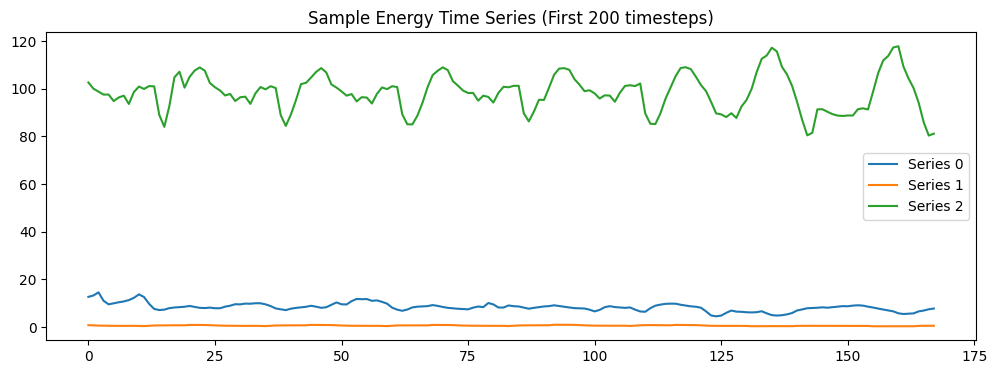

In [13]:
# Plot a few sample time series
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
for i in range(min(3, num_series)):
    plt.plot(X_raw[i, :200], label=f"Series {i}")
plt.title("Sample Energy Time Series (First 200 timesteps)")
plt.legend()
plt.show()

In [14]:
label_name = "cooling_ON"


INFO:p-2606385:t-131494590719808:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:p-2606385:t-131494590719808:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


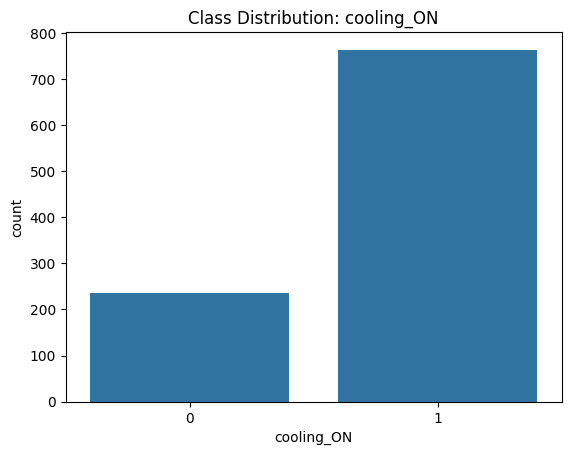

cooling_ON
1    0.764
0    0.236
Name: proportion, dtype: float64


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=labels_df[label_name])
plt.title(f"Class Distribution: {label_name}")
plt.show()

print(labels_df[label_name].value_counts(normalize=True))


In [16]:
import numpy as np

def extract_features(series):
    return [
        series.mean(),
        series.std(),
        series.min(),
        series.max(),
        np.percentile(series, 25),
        np.percentile(series, 50),
        np.percentile(series, 75),
        np.sum(np.diff(series)**2),   # roughness
    ]


In [20]:
X = []
for col in energy_df.columns:
    if col == "Timestamp":
        continue
    ts = energy_df[col].values
    X.append(extract_features(ts))

X = np.array(X)
y = labels_df[label_name].values

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (1000, 8)
Target shape: (1000,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    labels_df.values,
    test_size=0.2,
    random_state=42
)


In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.multioutput import MultiOutputClassifier

dummy = DummyClassifier(strategy="most_frequent")


dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [24]:
from sklearn.metrics import classification_report, f1_score

def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred))


In [29]:
# evaluate(y_test, y_pred_dummy, "Dummy Baseline")
# evaluate(y_test, y_pred_rf, "Random Forest")


## Loading EnergyTSPulse

In [ ]:
from tsfm_public.models.tspulse import TSPulseForClassification

model = TSPulseForClassification.from_pretrained(
    "sriv-naman-iisc/Energy-FM-v1",
    revision="energy-tspulse"
)

In [2]:
class ClassificationDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return { "past_values": self.X[idx], "target_values": self.y[idx] }



In [3]:
import torch
import numpy as np
from tqdm import tqdm

def get_predictions(model, dataloader, device):
    """
    Runs inference and returns predicted labels and true labels.
    """
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):

            # Move tensors to device
            inputs = {k: v.to(device) for k, v in batch.items() if k != "target_values"}
            labels = batch["target_values"].to(device)

            # Observed mask
            inputs["past_observed_mask"] = (inputs["past_values"] != 0.0)

            # Forward pass
            outputs = model(**inputs)
            logits = outputs.prediction_outputs

            # If temporal dimension exists → average
            if logits.dim() > 2:
                logits = logits.mean(dim=1)

            labels = labels.view(-1)

            preds = torch.argmax(logits, dim=-1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()


In [18]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def compute_classification_metrics(y_true, y_pred, num_labels):
    """
    Computes standard classification metrics.
    """
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    labels = list(range(num_labels))
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
        output_dict=True
    )

    precision_macro = report_dict["macro avg"]["precision"]
    recall_macro = report_dict["macro avg"]["recall"]

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "report_dict": report_dict
    }


In [19]:
def compute_energy_statistics(y_true, y_pred, X_test_raw):
    """
    Computes mean energy for true positives and predicted positives.
    """
    stats = {}

    if np.any(y_true == 1):
        stats["true_mean_label_1"] = X_test_raw[y_true == 1].mean()
    else:
        stats["true_mean_label_1"] = np.nan

    if np.any(y_pred == 1):
        stats["predicted_mean_label_1"] = X_test_raw[y_pred == 1].mean()
    else:
        stats["predicted_mean_label_1"] = np.nan

    stats["predicted_positives_count"] = np.sum(y_pred == 1)

    return stats


In [20]:
def print_report(y_true, y_pred, num_labels, label_name):
    """
    Prints formatted classification report.
    """
    labels = list(range(num_labels))
    target_names = [f"class_{i}" for i in labels]

    print("\n" + "=" * 50)
    print(f"Classification Report: {label_name}")
    print("=" * 50)

    print(classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0
    ))

    print("=" * 50 + "\n")


In [21]:
def evaluate_model(model, dataloader, device, X_test_raw, label_name, num_labels):

    # 1️⃣ Get predictions
    y_pred, y_true = get_predictions(model, dataloader, device)

    # 2️⃣ Compute metrics
    metrics = compute_classification_metrics(y_true, y_pred, num_labels)

    # 3️⃣ Compute energy stats
    energy_stats = compute_energy_statistics(y_true, y_pred, X_test_raw)

    # 4️⃣ Print report
    print_report(y_true, y_pred, num_labels, label_name)

    # 5️⃣ Merge results
    return {**metrics, **energy_stats}


### Data Loading and Exploratory Data Analysis (EDA)

In this section, we:

1. Load the raw energy time series data.
2. Inspect dataset shape and structure.
3. Check for missing values.
4. Analyze basic statistics of the time series.
5. Visualize example series.

This helps us understand the distribution, length, and quality of the data
before applying preprocessing steps such as truncation and padding.


In [23]:
# ===============================
# --- Preprocessing ---
# ===============================

# Define fixed context length
context_length = 512

# Initialize processed array
X_processed = np.zeros((num_series, context_length))

for i in tqdm(range(num_series), desc="Processing Series"):
    
    # Extract single series
    series = X_raw[i, :]
    
    # Replace NaN values with 0
    series = np.nan_to_num(series, nan=0.0)
    
    # Truncate or pad to fixed context length
    if len(series) > context_length:
        X_processed[i, :] = series[:context_length]
    else:
        X_processed[i, :len(series)] = series

# Add channel dimension
X_processed = X_processed[:, :, np.newaxis]

print("Final processed shape:", X_processed.shape)


Processing Series: 100%|██████████| 1000/1000 [00:00<00:00, 190945.28it/s]

Final processed shape: (1000, 512, 1)


In [ ]:
# ===============================
# --- Main Training Setup ---
# ===============================

# Target labels to fine-tune classification models on
target_labels = [
    "cooling_ON",
    "fans_ON",
    "heat_rejection_ON",
    "heating_ON",
    "refrigeration_ON",
    "water_systems_ON"
]


# Directory to store fine-tuned models and results
base_output_dir = "./finetuned_classification_manual_loop"
os.makedirs(base_output_dir, exist_ok=True)

# Select device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dictionary to store final evaluation results for all labels
all_results = {}

INFO:p-2591914:t-131372967085888:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-2591914:t-131372967085888:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
Some weights of TSPulseForClassification were not initialized from the model checkpoint at sriv-naman-iisc/Energy-FM-v1 and are newly initialized: ['decoder_with_head.head.head_norm.norm.bias', 'decoder_with_head.head.head_norm.norm.weight', 'decoder_with_head.head.loc_scale_norm.bias', 'decoder_with_head.head.loc_scale_norm.weight', 'decoder_with_head.head.projection.bias', 'decoder_with_head.head.projection.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
def prepare_label_data(X_processed, labels_df, label_name):
    if label_name not in labels_df.columns:
        return None

    y_raw = labels_df[label_name].values
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y_raw)

    if len(np.unique(y_encoded)) <= 1:
        return None

    X_train, X_val, y_train, y_val = train_test_split(
        X_processed,
        y_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_encoded
    )

    return X_train, X_val, y_train, y_val, len(np.unique(y_encoded))


In [27]:
def create_dataloaders(X_train, X_val, y_train, y_val, batch_size=32):

    train_dataset = ClassificationDataset(X_train, y_train)
    val_dataset   = ClassificationDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader


In [28]:
def compute_class_weights(y_train, num_labels, device):
    y_flat = y_train.ravel()
    class_counts = np.bincount(y_flat, minlength=num_labels)

    weights = len(y_flat) / (num_labels * (class_counts + 1e-6))
    weights = torch.tensor(weights, dtype=torch.float, device=device)

    return weights


In [30]:
def train_one_epoch(model, dataloader, optimizer, loss_fct, device):

    model.train()
    total_loss = 0.0

    for batch in tqdm(dataloader):

        inputs = {k: v.to(device) for k, v in batch.items() if k != "target_values"}
        labels = batch["target_values"].to(device).view(-1)

        inputs["past_observed_mask"] = (inputs["past_values"] != 0.0)

        optimizer.zero_grad()

        outputs = model(**inputs)
        logits = outputs.prediction_outputs

        if logits.dim() > 2:
            logits = logits.mean(dim=1)

        loss = loss_fct(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


In [31]:
def train_model(model, train_loader, val_loader, device,
                X_val_raw, label_name, num_labels,
                epochs=50, lr=1e-5):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fct  = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):

        avg_loss = train_one_epoch(
            model, train_loader, optimizer, loss_fct, device
        )

        eval_results = evaluate_model(
            model, val_loader, device,
            X_val_raw, label_name, num_labels
        )

        print(
            f"Epoch {epoch+1} | "
            f"Loss: {avg_loss:.4f} | "
            f"Val Acc: {eval_results['accuracy']:.4f} | "
            f"Val F1: {eval_results['f1_macro']:.4f}"
        )

    return model


In [32]:
def run_label_experiment(label_name):

    data = prepare_label_data(X_processed, labels_df, label_name)

    if data is None:
        print(f"Skipping {label_name}")
        return None

    X_train, X_val, y_train, y_val, num_labels = data

    train_loader, val_loader = create_dataloaders(
        X_train, X_val, y_train, y_val
    )

    model = initialize_model(pretrained_model_path, num_labels, device)

    trained_model = train_model(
        model,
        train_loader,
        val_loader,
        device,
        X_val.squeeze(),
        label_name,
        num_labels,
        epochs=50
    )

    return trained_model


In [33]:
all_results = {}

for label_name in target_labels:

    print("=" * 60)
    print(f"Training for label: {label_name}")

    model = run_label_experiment(label_name)

    if model is None:
        continue

    final_results = evaluate_model(
        model,
        val_loader,
        device,
        X_val.squeeze(),
        label_name,
        num_labels
    )

    all_results[label_name] = final_results


INFO:p-2591914:t-131372967085888:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-2591914:t-131372967085888:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-2591914:t-131372967085888:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-2591914:t-131372967085888:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-2591914:t-131372967085888:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-2591914:t-131372967085888:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-2591914:t-131372967085888:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-2591914:t-131372967085888:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-2591914:t-131372967085888:modeling_tspulse.py:_init_weights:Initializing 

Training for label: cooling_ON


Evaluating: 100%|██████████| 7/7 [00:00<00:00, 355.56it/s]



Classification Report: cooling_ON
              precision    recall  f1-score   support

     class_0       0.38      0.66      0.48        47
     class_1       0.90      0.30      0.45       153

   micro avg       0.58      0.39      0.46       200
   macro avg       0.64      0.48      0.47       200
weighted avg       0.78      0.39      0.46       200


Epoch 1 | Loss: 1.1773 | Val Acc: 0.3850 | Val F1: 0.3105


Evaluating: 100%|██████████| 7/7 [00:00<00:00, 685.49it/s]


...

Evaluating: 100%|██████████| 7/7 [00:00<00:00, 670.66it/s]



Classification Report: cooling_ON
              precision    recall  f1-score   support

     class_0       0.00      0.00      0.00        47
     class_1       0.77      1.00      0.87       153

    accuracy                           0.77       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.59      0.77      0.66       200


Epoch 49 | Loss: 0.5505 | Val Acc: 0.7650 | Val F1: 0.4334


Evaluating: 100%|██████████| 7/7 [00:00<00:00, 667.73it/s]



Classification Report: cooling_ON
              precision    recall  f1-score   support

     class_0       0.00      0.00      0.00        47
     class_1       0.77      1.00      0.87       153

    accuracy                           0.77       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.59      0.77      0.66       200


Epoch 50 | Loss: 0.5546 | Val Acc: 0.7650 | Val F1: 0.4334


NameError: name 'val_loader' is not defined

In [ ]:
def summarize_results(all_results, filename):

    results_df = pd.DataFrame(all_results).T
    print(results_df)

    with open(filename, "w") as f:
        f.write(results_df.to_string())

    print(f"Summary saved to {filename}")
